Table of Contents

1] Importing Required Libraries
2] Data Cleaning and EDA
3] Customer retention Analysis
4] RFM Analysis
5] Cohort Analysis
6] Customer Lifetime Value
7] Delivery Impact on Reviews
8] Product Success Analysis

i) Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata

In [3]:
customers = pd.read_csv(r"C:\Users\gk442\OneDrive\Desktop\Brazalian_Dataset\olist_customers_dataset.csv")
geolocation = pd.read_csv(r"C:\Users\gk442\OneDrive\Desktop\Brazalian_Dataset\olist_geolocation_dataset.csv")
order_items = pd.read_csv(r"C:\Users\gk442\OneDrive\Desktop\Brazalian_Dataset\olist_order_items_dataset.csv")
order_payments  = pd.read_csv(r"C:\Users\gk442\OneDrive\Desktop\Brazalian_Dataset\olist_order_payments_dataset.csv")
order_reviews  = pd.read_csv(r"C:\Users\gk442\OneDrive\Desktop\Brazalian_Dataset\olist_order_reviews_dataset.csv")
orders  = pd.read_csv(r"C:\Users\gk442\OneDrive\Desktop\Brazalian_Dataset\olist_orders_dataset.csv")
products  = pd.read_csv(r"C:\Users\gk442\OneDrive\Desktop\Brazalian_Dataset\olist_products_dataset.csv")
sellers  = pd.read_csv(r"C:\Users\gk442\OneDrive\Desktop\Brazalian_Dataset\olist_sellers_dataset.csv")
product_category_name_translation  = pd.read_csv(r"C:\Users\gk442\OneDrive\Desktop\Brazalian_Dataset\product_category_name_translation.csv")

Data Cleaning and EDA 

1. Customers data :-

In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [7]:
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str)

In [8]:
customers['customer_zip_code_prefix'].str.len().value_counts()

customer_zip_code_prefix
5    75446
4    23995
Name: count, dtype: int64

In [9]:
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].str.zfill(5)

In [10]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [13]:
customers.duplicated().sum()

np.int64(0)

In [15]:
customers['customer_unique_id'].duplicated().sum()

np.int64(3345)

In [16]:
# Group the unique IDs to see how many orders each person placed.
order_counts = customers.groupby('customer_unique_id')['customer_id'].count()
order_distribution = order_counts.value_counts().sort_index()
print(order_distribution)

customer_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


2. Geolocation Data:-

In [17]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [18]:
geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


In [19]:
geolocation['geolocation_zip_code_prefix'] = geolocation['geolocation_zip_code_prefix'].astype(str)
geolocation['geolocation_zip_code_prefix'] = geolocation['geolocation_zip_code_prefix'].str.zfill(5)

In [20]:
geolocation.duplicated().sum()

np.int64(261831)

In [21]:
geolocation[geolocation.duplicated()]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,01046,-23.546081,-46.644820,sao paulo,SP
44,01046,-23.546081,-46.644820,sao paulo,SP
65,01046,-23.546081,-46.644820,sao paulo,SP
66,01009,-23.546935,-46.636588,sao paulo,SP
67,01046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [22]:
geolocation.value_counts().value_counts().sort_index()

count
1      610158
2       81264
3       22656
4        9406
5        4852
        ...  
102         1
126         1
127         1
189         1
314         1
Name: count, Length: 70, dtype: int64

In [23]:
geolocation['geolocation_city'] = geolocation['geolocation_city'].str.lower().str.strip()

In [24]:
def normalize_city(text):
    return unicodedata.normalize('NFKD', text).encode('ascii','ignore').decode('utf-8')
geolocation['geolocation_city'] = geolocation['geolocation_city'].apply(normalize_city)

In [25]:
geolocation_clean = geolocation.drop_duplicates()

In [26]:
geolocation_final = geolocation_clean.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

3. Order Items

In [27]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [28]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [29]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])
order_items['total_item_price'] = order_items['price'] + order_items['freight_value']

In [30]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
total_item_price       0
dtype: int64

In [31]:
order_items.duplicated().sum()

np.int64(0)

In [32]:
order_items['shipping_limit_date'].dt.year.value_counts()

shipping_limit_date
2018    62511
2017    49765
2016      370
2020        4
Name: count, dtype: int64

In [ ]:
order_items = order_items[order_items['shipping_limit_date'].dt.year <= 2018]
# Four records with shipping_limit_date in 2020 were identified as anomalies since the dataset primarily spans from 2016 to 2018.
# These records were removed to maintain temporal consistency in the analysis.

In [34]:
order_items.describe()

,order_item_id,shipping_limit_date,price,freight_value,total_item_price
count,112646.000000,112646,112646.000000,112646.000000,112646.000000
mean,1.197832,2018-01-07 14:56:26.712683,120.654952,19.989678,140.644630
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000,6.080000
25%,1.000000,2017-09-20 20:55:12,39.900000,13.080000,55.220000
50%,1.000000,2018-01-26 13:59:30,74.990000,16.260000,92.320000
75%,1.000000,2018-05-10 14:30:19,134.900000,21.150000,157.927500
max,21.000000,2018-09-18 21:10:15,6735.000000,409.680000,6929.310000
std,0.705132,NaN,183.637058,15.805705,190.727629


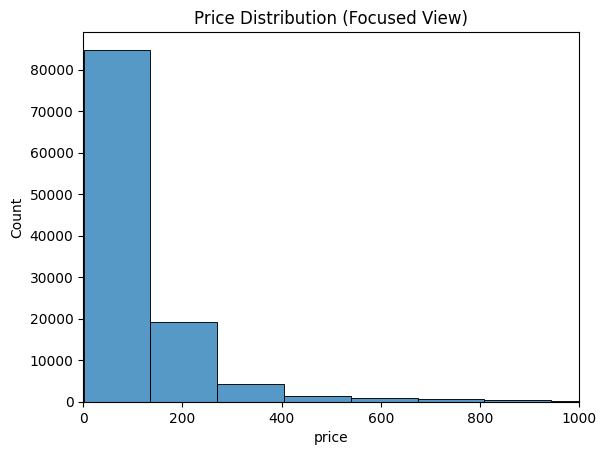

In [35]:
sns.histplot(order_items['price'], bins=50)
plt.xlim(0, 1000)   # remove extreme outliers for visibility
plt.title("Price Distribution (Focused View)")
plt.show()

The product price distribution is highly right-skewed, indicating that the majority of items sold on the platform fall within a low to mid-price range (below 200).

A small number of high-priced items create a long tail in the distribution, suggesting the presence of premium or luxury products.

In [36]:
# Orders With Multiple item
order_counts = order_items.groupby("order_id")["order_item_id"].max()
order_counts.value_counts()

order_item_id
1     88861
2      7515
3      1322
4       505
5       204
6       198
7        22
8         8
10        8
12        5
11        4
9         3
20        2
15        2
14        2
13        1
21        1
Name: count, dtype: int64

In [37]:
order_value = order_items.groupby("order_id")["total_item_price"].sum()

In [38]:
order_value.describe()

count    98663.000000
mean       160.577471
std        220.468588
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: total_item_price, dtype: float64

4. Order Payments Data

In [ ]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [40]:
order_payments.isnull().sum().sum()

np.int64(0)

In [41]:
order_payments.duplicated().sum()

np.int64(0)

In [42]:
order_payments[order_payments['payment_value']==0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


9 transactions have a payment value of zero, primarily associated with voucher-based payments. This indicates that certain orders were fully covered by promotional credits or vouchers. Additionally, a few records contain an undefined payment type, which may represent system placeholders or incomplete payment records.

In [43]:
# Removing zero payment value orders for revenue analysis
order_payment_revenue_analysis = order_payments[order_payments["payment_value"] > 0]

In [44]:
order_payment_revenue_analysis.describe()

,payment_sequential,payment_installments,payment_value
count,103877.000000,103877.000000,103877.000000
mean,1.092340,2.853509,154.113732
std,0.704312,2.687112,217.498755
min,1.000000,0.000000,0.010000
25%,1.000000,1.000000,56.820000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.840000
max,29.000000,24.000000,13664.080000


In [45]:
order_payments.payment_type.value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [46]:
order_payments[order_payments["payment_type"] == "not_defined"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


In [47]:
order_payments["payment_type"] = order_payments["payment_type"].replace("not_defined", "unknown")

Credit cards dominate online transactions in this marketplace

5. Orders Data

In [48]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [49]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [50]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [51]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


Missing Values Analysis

In [52]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [53]:
orders[
    (orders['order_approved_at'].isna()) &
    (orders['order_delivered_customer_date'].isna()) &
    (orders['order_delivered_carrier_date'].isna())
]['order_status'].value_counts()

order_status
canceled    141
created       5
Name: count, dtype: int64

In [54]:
orders[orders['order_approved_at'].isna()]['order_status'].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [55]:
orders[orders['order_delivered_carrier_date'].isna()]['order_status'].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

In [56]:
orders[orders['order_delivered_customer_date'].isna()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Orders with canceled or unavailable status often lack approval and delivery timestamps because they did not progress beyond the early order stages.

Orders marked as shipped but missing delivery timestamps likely represent items still in transit or awaiting delivery confirmation.

A small number of delivered orders missing approval or delivery timestamps indicate minor data inconsistencies in the system records.

i. Remove Delivered Orders Without Approval Time

In [57]:
 # Orders delivered but have no approval time.
orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_approved_at'].isna())
].shape[0]

14

In [58]:
 # Remove orders that were delivered but have no approval time.

orders = orders[~(
    (orders['order_status'] == 'delivered') &
    (orders['order_approved_at'].isna())
)]

ii. Remove Delivered Orders Without Delivery Date

In [59]:
# Orders delivered but have no delivery date.

orders[(orders['order_status'] == 'delivered') &
    (orders["order_delivered_customer_date"].isna())
    ].shape[0]

8

In [60]:
orders = orders[~((orders['order_status'] == 'delivered') &
    (orders["order_delivered_customer_date"].isna())
        )]

Purchase Day / Month

In [61]:
orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_day'] = orders['order_purchase_timestamp'].dt.day
orders['purchase_weekday'] = orders['order_purchase_timestamp'].dt.day_name()

Delivery Time

In [62]:
orders['delivery_time'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

In [63]:
orders['delivery_time'].describe()

count    96462.000000
mean        12.093996
std          9.552390
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time, dtype: float64

Order Processing Time

In [64]:
orders['processing_time'] = (
    orders['order_approved_at'] -
    orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

In [65]:
orders['processing_time'].describe()

count    99273.000000
mean        10.419913
std         26.038893
min          0.000000
25%          0.215000
50%          0.343333
75%         14.581944
max       4509.180556
Name: processing_time, dtype: float64

Delivery delay Time

In [66]:
orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

In [67]:
def delivery_status(x):
    if pd.isna(x):
        return None
    elif x < 0:
        return "Early"
    elif x == 0:
        return "On Time"
    else:
        return "Late"

orders['delivery_status'] = orders['delivery_delay'].apply(delivery_status)

In [68]:
orders['delivery_delay'].describe()

count    96462.000000
mean       -11.875391
std         10.183586
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64

The dataset have overestimated delivery dates

In [69]:
orders["is_late"] = orders["delivery_delay"]>0

In [70]:
orders["is_late"].value_counts()

is_late
False    92884
True      6535
Name: count, dtype: int64

About 89% of orders were delivered earlier than the estimated delivery date, while only about 9.5% experienced delays.

6. Products Dataset

In [71]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [72]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [73]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [75]:
products['product_category_name'].fillna('unknown', inplace=True)

C:\Users\gk442\AppData\Local\Temp\ipykernel_12332\2058816560.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  products['product_category_name'].fillna('unknown', inplace=True)


0                               perfumaria
1                                    artes
2                            esporte_lazer
3                                    bebes
4                    utilidades_domesticas
                       ...                
32946                     moveis_decoracao
32947    construcao_ferramentas_iluminacao
32948                      cama_mesa_banho
32949               informatica_acessorios
32950                      cama_mesa_banho
Name: product_category_name, Length: 32951, dtype: str

In [76]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [77]:
products['product_volume_cm3'] = (
    products['product_length_cm'] *
    products['product_height_cm'] *
    products['product_width_cm']
)

In [78]:
def size_category(v):
    if v < 1000:
        return 'small'
    elif v < 10000:
        return 'medium'
    else:
        return 'large'

products['size_category'] = products['product_volume_cm3'].apply(size_category)

In [79]:
products['size_category'].value_counts()

size_category
medium    17887
large     12859
small      2205
Name: count, dtype: int64

7. Reviews Dataset

In [80]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [81]:
order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [82]:
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

In [83]:
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [84]:
order_reviews.duplicated().sum()

np.int64(0)

In [85]:
order_reviews['review_score'].unique()

array([4, 5, 1, 3, 2])

In [86]:
order_reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [87]:
order_reviews.groupby('review_score')['review_comment_message'].count()

review_score
1     8745
2     2145
3     3557
4     5976
5    20554
Name: review_comment_message, dtype: int64

In [88]:
order_reviews[order_reviews.isna().any(axis = 1)]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


In [89]:
order_reviews.groupby('review_score')['review_comment_message'].apply(lambda x: x.notnull().mean())

review_score
1    0.765494
2    0.680736
3    0.434894
4    0.312193
5    0.358533
Name: review_comment_message, dtype: float64

In [90]:
order_reviews['review_length'] = order_reviews['review_comment_message'].str.len()

In [91]:
order_reviews.groupby('review_score')['review_length'].mean()

review_score
1    99.941910
2    96.845688
3    83.331740
4    61.733601
5    51.839496
Name: review_length, dtype: float64

Unhappy Customers are much more likely to write lengthy reviews.

In [92]:
order_reviews['response_time_in _days'] = (
    order_reviews['review_answer_timestamp'] -
    order_reviews['review_creation_date']
).dt.days

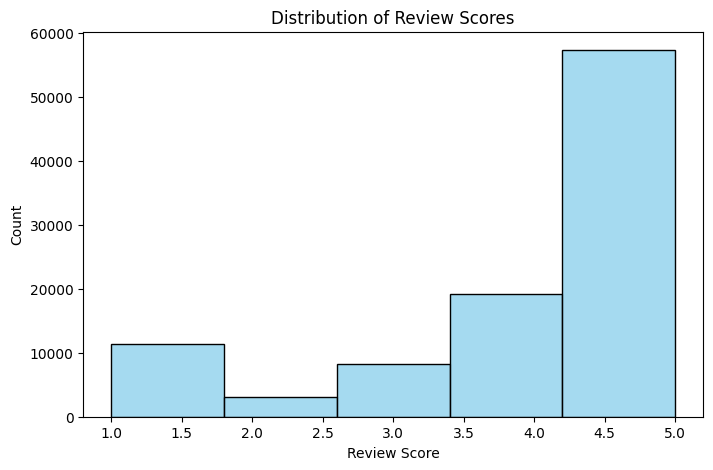

In [93]:
plt.figure(figsize=(8,5))
sns.histplot(order_reviews['review_score'], bins=5, kde=False, color='skyblue')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()

C:\Users\gk442\AppData\Local\Temp\ipykernel_12332\1862978680.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='review_score', data=order_reviews, palette='viridis')


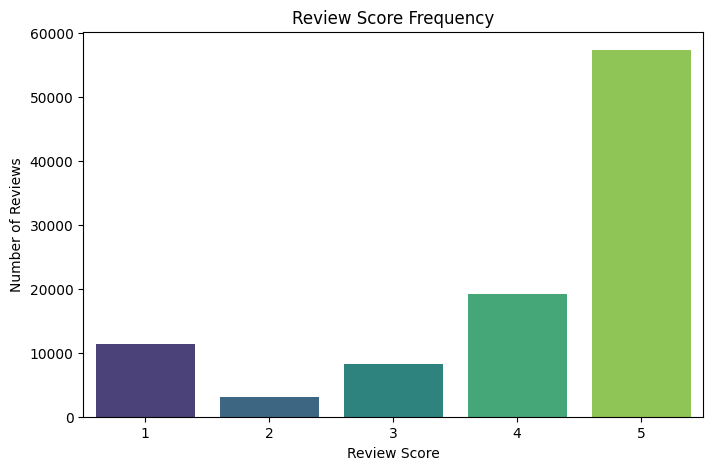

In [94]:
plt.figure(figsize=(8,5))
sns.countplot(x='review_score', data=order_reviews, palette='viridis')
plt.title('Review Score Frequency')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.show()

8. Sellers Dataset

In [95]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [96]:
sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [97]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [98]:
sellers.duplicated().sum()

np.int64(0)

In [99]:
sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype(str).str.zfill(5)

In [100]:
(sellers['seller_state'].value_counts(normalize=True) * 100).round(2)

seller_state
SP    59.74
PR    11.28
MG     7.88
SC     6.14
RJ     5.53
RS     4.17
GO     1.29
DF     0.97
ES     0.74
BA     0.61
CE     0.42
PE     0.29
PB     0.19
RN     0.16
MS     0.16
MT     0.13
RO     0.06
SE     0.06
AC     0.03
PI     0.03
MA     0.03
AM     0.03
PA     0.03
Name: proportion, dtype: float64

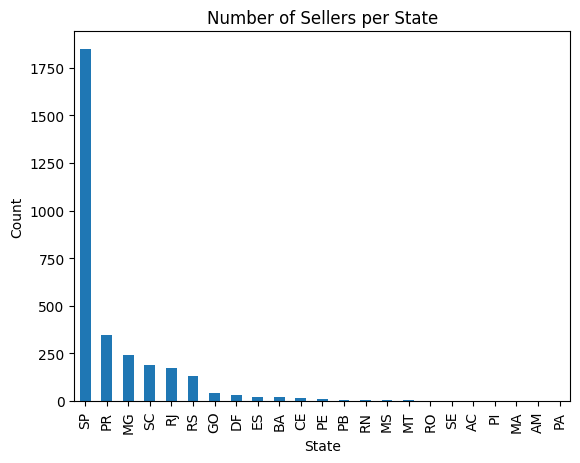

In [101]:
sellers['seller_state'].value_counts().plot(kind='bar')
plt.title('Number of Sellers per State')
plt.xlabel('State')
plt.ylabel('Count')
plt.show()

Customer Retention Analysis

In [102]:
#Total unique customers 
total_customers = customers['customer_unique_id'].nunique()

# Repeat customers 
repeat_customers = (customers['customer_unique_id'].value_counts() > 1).sum()

# Retention Rate
retention_rate = (repeat_customers / total_customers) * 100

Total Unique Customers: 96,096
Repeat Customer Count: 2,997
Retention Rate: 3.12
The analysis reveals a Customer Retention Rate of 3.12%, indicating a high Churn Rate where 96.88% of the acquisition is composed of one-time shoppers. While the platform successfully reached 96,096 unique customers, the business model currently relies on constant new user acquisition rather than a deep Loyal Customer base, suggesting an opportunity to implement targeted re-engagement strategies to increase Customer Lifetime Value (CLV).

RFM Analysis:-

In [103]:
orders_delivered = orders[orders["order_status"] == "delivered"]

In [104]:
payment_agg = order_payments.groupby("order_id", as_index=False).agg(total_payment = ("payment_value", "sum"))


rfm_df = orders_delivered[["order_id", "customer_id", "order_purchase_timestamp"]] \
    .merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="inner") \
    .merge(payment_agg, on="order_id", how="left")

In [105]:
rfm_df.duplicated().sum()

np.int64(0)

In [106]:
rfm_df.head()

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,total_payment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,28.62


In [107]:
snapshot_date = rfm_df["order_purchase_timestamp"].max() + pd.Timedelta(days = 1)

In [108]:
rfm = rfm_df.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "count"),
    monetary=("total_payment", "sum")
)

In [109]:
rfm.head()

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [110]:
# Recency Score (Lower recency is considered better, so scores are assigned in reverse order to give higher scores to more recent customers).
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])

# Frequency Score
rfm["F_score"] = pd.cut( rfm["frequency"], bins=[0,1,2,3,5,20],labels=[1,2,3,4,5])

# Monetary Score
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])

In [111]:
rfm.head()

,recency,frequency,monetary,R_score,F_score,M_score
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4


In [112]:
def segment_customer(row):
    r = int(row["R_score"])
    f = int(row["F_score"])
    m = int(row["M_score"])

    
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Lost Customers"
    elif m >= 4:
        return "Big Spenders"
    else:
        return "Others"     

rfm["segment"] = rfm.apply(segment_customer, axis=1)

In [113]:
rfm.head(20)

,recency,frequency,monetary,R_score,F_score,M_score,segment
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,New Customers
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,New Customers
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,Lost Customers
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,Lost Customers
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,Lost Customers
0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,4,1,4,New Customers
00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,4,1,1,New Customers
00053a61a98854899e70ed204dd4bafe,183,1,419.18,3,1,5,Big Spenders
0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,1,1,4,Lost Customers


In [114]:
rfm["segment"].value_counts()

segment
New Customers      37305
Lost Customers     37132
Others             11288
Big Spenders        7384
Loyal Customers      126
At Risk               69
Champions             33
Name: count, dtype: int64

<Axes: title={'center': 'Customer Segments'}, xlabel='segment'>

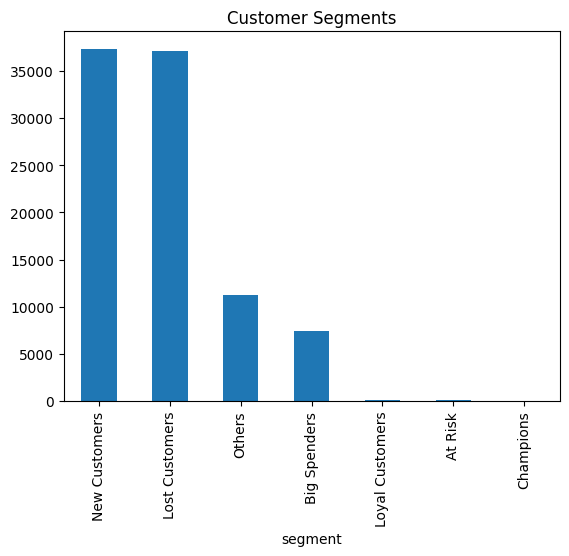

In [115]:
rfm["segment"].value_counts().plot(kind="bar", title="Customer Segments")

Cohort Analysis:-

In [116]:
cohort_df = orders_delivered[["order_id", "customer_id", "order_purchase_timestamp"]] \
    .merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how = "left")

In [117]:
#order_month
cohort_df["order_month"] = cohort_df["order_purchase_timestamp"].dt.to_period("M")

#cohort_month
cohort_df["cohort_month"] = cohort_df.groupby("customer_unique_id")["order_month"].transform("min")

#cohort_index
cohort_df["cohort_index"] = (
    (cohort_df["order_month"].dt.year - cohort_df["cohort_month"].dt.year) * 12 +
    (cohort_df["order_month"].dt.month - cohort_df["cohort_month"].dt.month)
)

In [118]:
# Build Retention Table
cohort_data = cohort_df.groupby(["cohort_month", "cohort_index"]) \
    .agg(customers=("customer_unique_id", "nunique")) \
    .reset_index()

In [119]:
cohort_data.head()

,cohort_month,cohort_index,customers
0,2016-09,0,1
1,2016-10,0,262
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1


In [120]:
# Pivot
cohort_pivot = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customers"
)

In [121]:
# Retention Rate
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

In [122]:
retention_clean = retention.fillna(0)
retention_clean = retention_clean.round(4) * 100

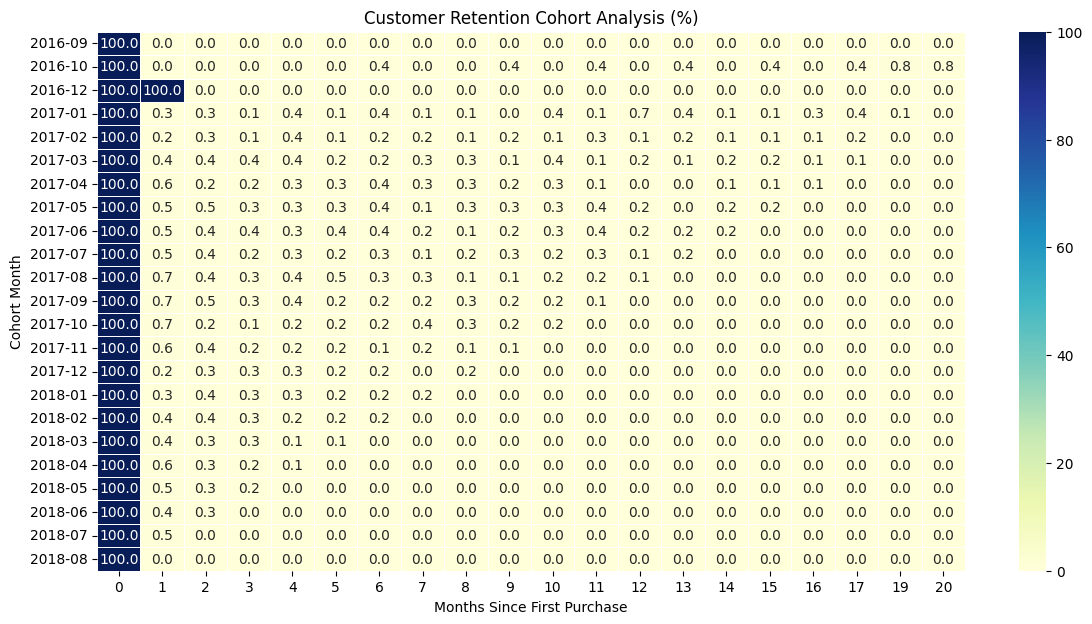

In [123]:
plt.figure(figsize=(14,7))

sns.heatmap(
    retention_clean,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Customer Retention Cohort Analysis (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

Customer retention is relatively low, with a significant proportion of users making only one purchase. This suggests the platform relies heavily on new customer

acquisition rather than repeat purchases, which is typical for marketplace-based e-commerce models.

Customer Lifetime Value :-
Total value a customer brings to the business over their entire relationship.

In [124]:
clv_df = (
    orders_delivered[
        ["order_id", "customer_id", "order_purchase_timestamp"]
    ]
    .merge(
        payment_agg,
        on="order_id",
        how="inner"
    )
    .merge(
        customers[
            ["customer_id", "customer_unique_id"]
        ],
        on="customer_id",
        how="inner"
    )
)

In [125]:
clv_df.head()

,order_id,customer_id,order_purchase_timestamp,total_payment,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,38.71,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,141.46,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,179.12,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,72.20,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,28.62,72632f0f9dd73dfee390c9b22eb56dd6


Customer Metrics

In [127]:
# Customer Behaviour Metrics

customer_metrics = clv_df.groupby("customer_unique_id").agg(
    total_revenue=("total_payment", "sum"),
    total_orders=("order_id", "nunique"),
    average_order_value=("total_payment", "mean"),
    first_purchase=("order_purchase_timestamp", "min"),
    last_purchase=("order_purchase_timestamp", "max")
)

Customer Lifetime:-

In [128]:
customer_metrics["lifetime_days"] = (
    customer_metrics["last_purchase"] -
    customer_metrics["first_purchase"]
).dt.days + 1

Purchase Frequency:-

In [ ]:
customer_metrics["purchase_frequency"] = (
    customer_metrics["total_orders"] /
    customer_metrics["lifetime_days"]
)

In [129]:
customer_metrics["CLV"] = (
    customer_metrics["average_order_value"] *
    customer_metrics["total_orders"]
)

In [130]:
customer_metrics[[
    "total_revenue",
    "total_orders",
    "average_order_value",
    "lifetime_days",
    "CLV"
]].head()

,total_revenue,total_orders,average_order_value,lifetime_days,CLV
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19,1,27.19
0000f46a3911fa3c0805444483337064,86.22,1,86.22,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62,1,43.62
0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89,1,196.89


Customer Segmentation based on CLV

In [131]:
q50 = customer_metrics["CLV"].quantile(0.50)
q75 = customer_metrics["CLV"].quantile(0.75)
q90 = customer_metrics["CLV"].quantile(0.90)
q99 = customer_metrics["CLV"].quantile(0.99)

In [132]:
def segment_customer(clv):
    
    if clv >= q99:
        return "Super VIP"
    
    elif clv >= q90:
        return "VIP"
    
    elif clv >= q75:
        return "High Value"
    
    elif clv >= q50:
        return "Mid Value"
    
    else:
        return "Low Value"

customer_metrics["segment"] = (
    customer_metrics["CLV"]
    .apply(segment_customer)
)

In [133]:
customer_metrics.head()

,total_revenue,total_orders,average_order_value,first_purchase,last_purchase,lifetime_days,CLV,segment
customer_unique_id,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,1,141.90,Mid Value
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,1,27.19,Low Value
0000f46a3911fa3c0805444483337064,86.22,1,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,1,86.22,Low Value
0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,1,43.62,Low Value
0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,1,196.89,High Value


In [134]:
# Segment Distribution
customer_segment = (
    customer_metrics["segment"]
    .value_counts()
)

In [135]:
# Revenue Contribution by Segments
revenue_by_segment = (
    customer_metrics
    .groupby("segment")["CLV"]
    .sum()
)

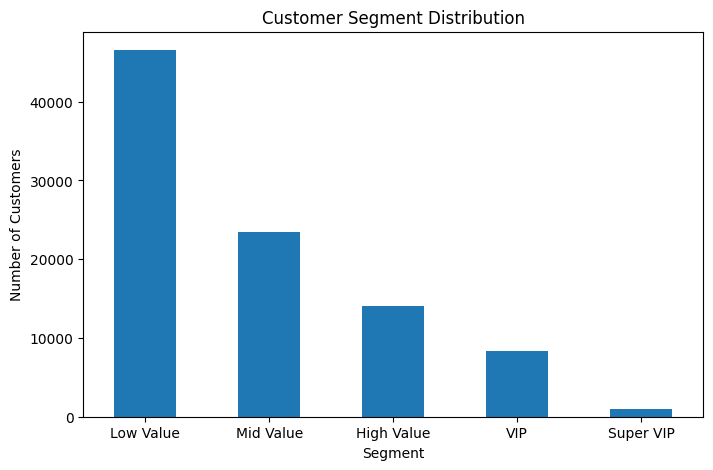

In [136]:
plt.figure(figsize=(8,5))

customer_segment.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

Revenue distribution is highly concentrated among high-value customer segments. The top 1–10% of customers contribute a disproportionately large share of total revenue, highlighting the importance of customer retention and personalized marketing strategies for premium customers

Delivery Impact on Reviews:-

In [137]:
delivery_df = orders[[ "order_id",
        "delivery_time",
        "processing_time",
        "delivery_delay",
        "delivery_status",
        "purchase_year",
        "purchase_month",
        "purchase_weekday"]]\
    .merge(order_reviews[["order_id", "review_score"]], on="order_id", how="inner")

Delivery Time vs Reviews:-

In [138]:
delivery_df.groupby("delivery_status")["review_score"].mean().sort_values(ascending=False)

delivery_status
Early      4.293568
On Time    4.033308
Late       2.271139
Name: review_score, dtype: float64

<Axes: xlabel='delivery_status'>

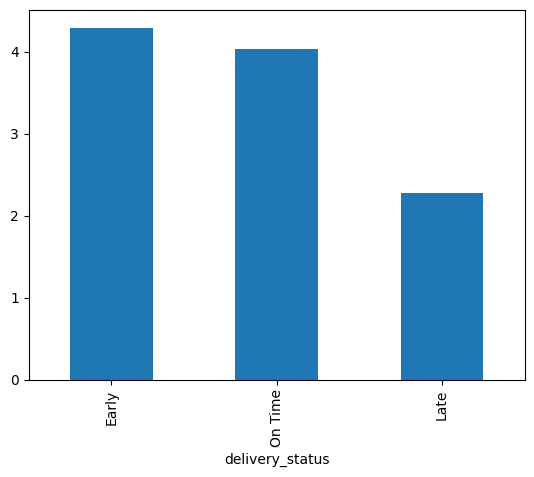

In [139]:
delivery_df.groupby("delivery_status")["review_score"].mean().sort_values(ascending=False).plot(kind="bar")

Slow seller processing impact customer satisfaction

In [140]:
delivery_df.groupby("processing_time")["review_score"].mean()

processing_time
0.000000       4.077399
0.088611       5.000000
0.089722       5.000000
0.090000       4.000000
0.090833       5.000000
                 ...   
741.443611     3.000000
781.028056     1.000000
784.045556     1.000000
1450.866389    1.000000
4509.180556    1.000000
Name: review_score, Length: 33263, dtype: float64

Customer ratings are highest for early deliveries, followed by on-time, and lowest for late deliveries, showing delivery speed directly impacts satisfaction.

Minor delays have little effect, but major delays particularly from sellers cause a sharp decline in ratings.

Product Success Analysis:-

In [141]:
product_df = order_items[["order_id", "product_id", "total_item_price"]] \
.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")

Category Level Analysis:-

i. Revenue

In [142]:
poduct_revenue_by_category = product_df.groupby("product_category_name")["total_item_price"].sum().sort_values(ascending=False)

In [143]:
top_20_percent = int(len(poduct_revenue_by_category) * .2)
top_products_categories = poduct_revenue_by_category.head(top_20_percent)
top_products_categories

product_category_name
beleza_saude              1441248.07
relogios_presentes        1305541.61
cama_mesa_banho           1241681.72
esporte_lazer             1156656.48
informatica_acessorios    1059272.40
moveis_decoracao           902511.79
utilidades_domesticas      777899.57
cool_stuff                 719329.95
automotivo                 685384.32
ferramentas_jardim         584219.21
brinquedos                 561372.55
bebes                      480118.00
perfumaria                 453338.71
telefonia                  394883.32
Name: total_item_price, dtype: float64

In [144]:
top_products_categories_ratio = top_products_categories.sum()/ poduct_revenue_by_category.sum()
top_products_categories_ratio

np.float64(0.7523629300027277)

20% products categories make 75% revenue.

ii. Demand

In [145]:
category_demand = product_df.groupby("product_category_name")["order_id"].count().sort_values(ascending=False)

In [146]:
category_demand.head(10)

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6960
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: order_id, dtype: int64

iii. Total Number of Orders in each Category

In [147]:
category_orders = product_df.groupby("product_category_name")["order_id"].nunique()

In [148]:
category_orders

product_category_name
agro_industria_e_comercio     182
alimentos                     450
alimentos_bebidas             227
artes                         202
artes_e_artesanato             23
                             ... 
sinalizacao_e_seguranca       140
tablets_impressao_imagem       79
telefonia                    4199
telefonia_fixa                217
utilidades_domesticas        5881
Name: order_id, Length: 73, dtype: int64

iv. Revenue Concentration

In [149]:
# Average Order Value per Category
category_aov = poduct_revenue_by_category / category_orders

In [150]:
category_perf = pd.concat(
    [poduct_revenue_by_category, category_demand, category_orders, category_aov],
    axis=1
)
category_perf.columns = ["revenue", "items_sold", "orders", "avg_order_value"]
category_perf_sorted = category_perf.sort_values(by = "revenue", ascending = False)

category_perf_sorted.head()

,revenue,items_sold,orders,avg_order_value
product_category_name,,,,
beleza_saude,1441248.07,9670,8836,163.110918
relogios_presentes,1305541.61,5991,5624,232.137555
cama_mesa_banho,1241681.72,11115,9417,131.855338
esporte_lazer,1156656.48,8641,7720,149.825969
informatica_acessorios,1059272.40,7827,6689,158.360353


Product Segmentation:-

In [151]:
rev_med = category_perf["revenue"].median()
ord_med = category_perf["orders"].median()

def product_segments(cat_data):
        if cat_data["revenue"] > rev_med and cat_data["orders"] > ord_med:
            return "Best Sellers"
        elif cat_data["revenue"] > rev_med:
            return "Premium"
        elif cat_data["orders"] > ord_med:
            return "High Volume Low Value"
        else:
            return "Underperforming"
    
category_perf["type"] = category_perf.apply(product_segments, axis=1)

In [152]:
category_perf.head(10)

,revenue,items_sold,orders,avg_order_value,type
product_category_name,,,,,
beleza_saude,1441248.07,9670,8836,163.110918,Best Sellers
relogios_presentes,1305541.61,5991,5624,232.137555,Best Sellers
cama_mesa_banho,1241681.72,11115,9417,131.855338,Best Sellers
esporte_lazer,1156656.48,8641,7720,149.825969,Best Sellers
informatica_acessorios,1059272.40,7827,6689,158.360353,Best Sellers
moveis_decoracao,902511.79,8334,6449,139.946006,Best Sellers
utilidades_domesticas,777899.57,6960,5881,132.273350,Best Sellers
cool_stuff,719329.95,3796,3632,198.053400,Best Sellers
automotivo,685384.32,4235,3897,175.874858,Best Sellers


I classified product categories based on whether their revenue and order volume were above or below the median, creating four segments: best sellers, premium, high-volume low-value, and underperforming.

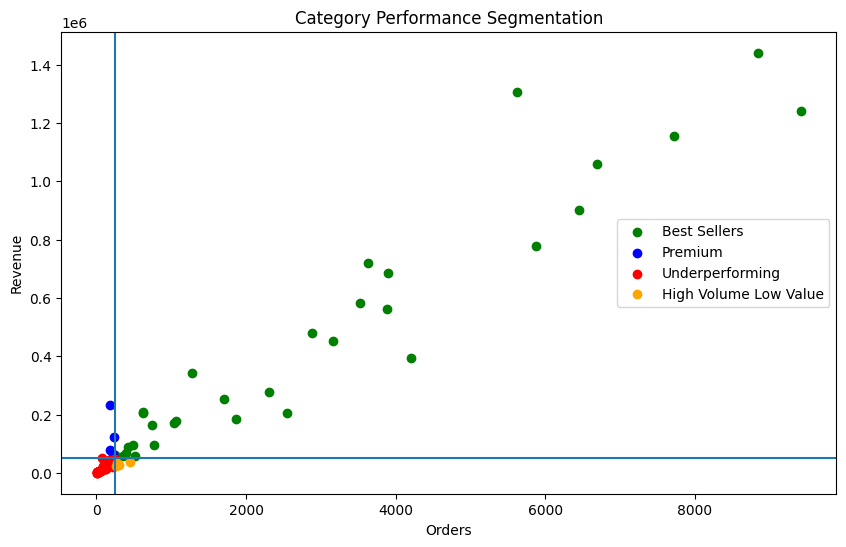

In [153]:
colors = {
    "Best Sellers": "green",
    "Premium": "blue",
    "High Volume Low Value": "orange",
    "Underperforming": "red"
}

plt.figure(figsize=(10,6))

for t in category_perf["type"].unique():
    subset = category_perf[category_perf["type"] == t]
    plt.scatter(subset["orders"], subset["revenue"], label=t, color = colors[t])

plt.axhline(y=rev_med)
plt.axvline(x=ord_med)

plt.legend()
plt.xlabel("Orders")
plt.ylabel("Revenue")
plt.title("Category Performance Segmentation")

plt.show()